#  Image Classification with Transfer Learning
### Using ResNet50 + Fine-Tuning on Oxford Flowers 102

---

**What we're building:**
A production-style image classifier that can identify 102 species of flowers
from photos — using a pre-trained ResNet50 model and fine-tuning it to our dataset.

**Why Transfer Learning?**
The Oxford Flowers dataset has only ~1000 training images.
Training a deep CNN from scratch on this would badly overfit.
Instead, we borrow ResNet50's knowledge (trained on 1.2M ImageNet images)
and adapt it to our flower classification task.

**Project Flow:**
1. Load & Explore Data
2. Preprocess & Augment
3. Build Model (ResNet50 + Custom Head)
4. Stage 1 Training — Feature Extraction
5. Stage 2 Training — Fine-Tuning
6. Evaluate — Accuracy, Top-5, Confusion Matrix

## 1. Environment Setup

Before anything else, we verify that our GPU is active.
Transfer learning with ResNet50 on CPU would take hours.
With a GPU, each training epoch takes under a minute.

In [1]:
import tensorflow as tf

print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load and Explore the Dataset

We use the Oxford Flowers 102 dataset loaded directly via
TensorFlow Datasets — no manual download needed.

Dataset breakdown:
- 102 flower categories
- 1020 training images (only 10 per class — very small)
- 1020 validation images
- 6149 test images

This small training size is exactly why we need transfer learning.

In [2]:
import tensorflow_datasets as tfds

(ds_train, ds_val, ds_test), info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

num_classes = info.features['label'].num_classes
train_size  = tf.data.experimental.cardinality(ds_train).numpy()
val_size    = tf.data.experimental.cardinality(ds_val).numpy()
test_size   = tf.data.experimental.cardinality(ds_test).numpy()

print(f"Number of classes : {num_classes}")
print(f"Train size        : {train_size}")
print(f"Validation size   : {val_size}")
print(f"Test size         : {test_size}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.7YEM7G_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.7YEM7G_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
Number of classes : 102
Train size        : 1020
Validation size   : 1020
Test size         : 6149


## 3. Visualize Sample Images

Before building anything, we look at the raw data.
This helps us understand what the model will actually see —
image quality, variation in angles, lighting, and backgrounds.

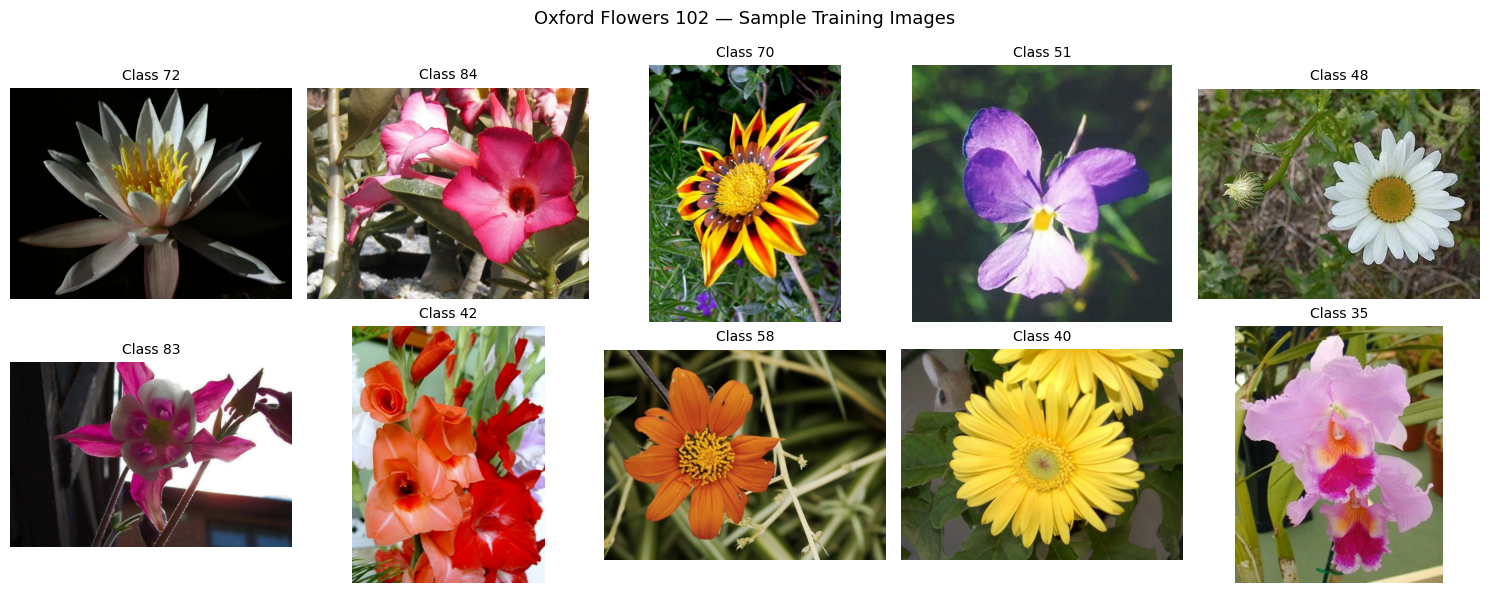

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (image, label) in enumerate(ds_train.take(10)):
    axes[i].imshow(image.numpy())
    axes[i].set_title(f"Class {label.numpy()}", fontsize=10)
    axes[i].axis('off')

plt.suptitle("Oxford Flowers 102 — Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocess and Augment

Raw images cannot go directly into ResNet50. Two things need to happen:

Preprocessing — resize every image to 224x224 (ResNet50's expected input)
and normalize pixel values using ResNet50's specific normalization formula.

Augmentation — applied only to training images. Since we have just 1020
training images, we artificially increase variety by randomly flipping,
adjusting brightness and contrast. This reduces overfitting.

Validation and test images only get preprocessed — never augmented.
Augmenting evaluation data would give us meaningless metrics.

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

def augment(image, label):
    image, label = preprocess(image, label)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

ds_train_ready = (ds_train
                  .shuffle(1000)
                  .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

ds_val_ready = (ds_val
                .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

ds_test_ready = (ds_test
                 .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

# Confirm shapes
for images, labels in ds_train_ready.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)


## 5. Build the Model

We load ResNet50 pre-trained on ImageNet and remove its original
classification head (which was built for 1000 classes).

We replace it with our own head for 102 flower classes:

ResNet50 base (frozen)
      ↓
GlobalAveragePooling2D — reduces (7, 7, 2048) to (2048,)
      ↓
Dense(256, relu) — learns flower-specific patterns
      ↓
Dropout(0.5) — prevents memorization
      ↓
Dense(102, softmax) — final prediction across 102 classes

In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def build_model(trainable_base=False):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = trainable_base

    if trainable_base:
        for layer in base_model.layers[:-30]:
            layer.trainable = False

    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(102, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

# Build Stage 1 model
model, base_model = build_model(trainable_base=False)

# Check trainable vs frozen
trainable     = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])

print(f"Trainable parameters     : {trainable:,}")
print(f"Non-trainable parameters : {non_trainable:,}")
print(f"Total parameters         : {trainable + non_trainable:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable parameters     : 550,758
Non-trainable parameters : 23,587,712
Total parameters         : 24,138,470


## 6. Stage 1 Training — Feature Extraction

The ResNet50 base is completely frozen.
Only our custom head (550K parameters) trains here.

We use three callbacks to make training smarter:

EarlyStopping — stops training if val_accuracy stops improving
for 5 consecutive epochs. Saves time and prevents overfitting.

ReduceLROnPlateau — if val_loss stops improving for 3 epochs,
learning rate is halved automatically. Helps squeeze more accuracy.

ModelCheckpoint — saves the best model weights automatically
based on highest val_accuracy seen during training.

Goal: reach a solid baseline accuracy before fine-tuning.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        'best_stage1_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train
history_stage1 = model.fit(
    ds_train_ready,
    epochs=15,
    validation_data=ds_val_ready,
    callbacks=callbacks_stage1
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.0144 - loss: 5.2755
Epoch 1: val_accuracy improved from None to 0.03922, saving model to best_stage1_model.keras

Epoch 1: finished saving model to best_stage1_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 625ms/step - accuracy: 0.0157 - loss: 5.0891 - val_accuracy: 0.0392 - val_loss: 4.4966 - learning_rate: 1.0000e-04
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0408 - loss: 4.5879
Epoch 2: val_accuracy improved from 0.03922 to 0.08529, saving model to best_stage1_model.keras

Epoch 2: finished saving model to best_stage1_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step - accuracy: 0.0324 - loss: 4.5402 - val_accuracy: 0.0853 - val_loss: 4.2946 - learning_rate: 1.0000e-04
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.0668 - loss: 4.2966
Epoch 3: val_accuracy improved from 0.08529 to 0.14118, saving model to best_stage1_model.keras

Epoch 3: finished saving model to best_stage1_mod

## 7. Plot Stage 1 Training Curves

Visualizing accuracy and loss over epochs tells us:
- Is the model actually learning? (accuracy should rise)
- Is it overfitting? (train accuracy much higher than val accuracy)
- Did the learning rate need adjustment?

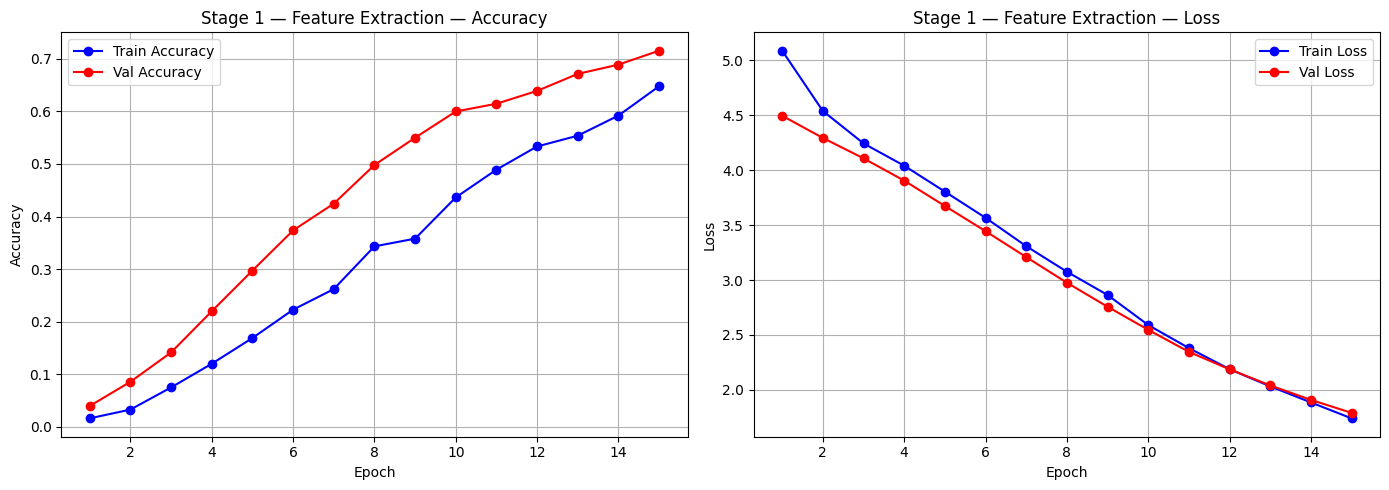

In [7]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, acc,     'b-o', label='Train Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', label='Val Accuracy')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, loss,     'b-o', label='Train Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_stage1, 'Stage 1 — Feature Extraction')

## 8. Stage 2 Training — Fine-Tuning

Stage 1 trained only the custom head.
Now we unfreeze the last 30 layers of ResNet50 and let them
slowly adapt their features toward flowers.

Key changes from Stage 1:
- Learning rate drops to 1e-5 (10x smaller than Stage 1)
  to avoid destroying the pre-trained weights
- Last 30 layers become trainable
- Earlier layers stay frozen — they learned universal features
  like edges and textures that are still useful

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Rebuild model with last 30 layers unfrozen
model_ft, base_model_ft = build_model(trainable_base=True)

# Load best weights from Stage 1 as starting point
model_ft.load_weights('best_stage1_model.keras')

# Compile with much smaller learning rate
model_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Check how many layers are now trainable
trainable     = sum([tf.size(w).numpy() for w in model_ft.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_ft.non_trainable_weights])

print(f"Trainable parameters     : {trainable:,}")
print(f"Non-trainable parameters : {non_trainable:,}")

# Callbacks
callbacks_stage2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        'best_stage2_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train
history_stage2 = model_ft.fit(
    ds_train_ready,
    epochs=20,
    validation_data=ds_val_ready,
    callbacks=callbacks_stage2
)

Trainable parameters     : 15,000,934
Non-trainable parameters : 9,137,536
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.3930 - loss: 2.5917
Epoch 1: val_accuracy improved from None to 0.72353, saving model to best_stage2_model.keras

Epoch 1: finished saving model to best_stage2_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 772ms/step - accuracy: 0.4039 - loss: 2.5470 - val_accuracy: 0.7235 - val_loss: 1.6934 - learning_rate: 1.0000e-05
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4595 - loss: 2.2189
Epoch 2: val_accuracy did not improve from 0.72353
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.4931 - loss: 2.1232 - val_accuracy: 0.7216 - val_loss: 1.6150 - learning_rate: 1.0000e-05
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5605 - loss: 1.9076
Epoch 3: val_accuracy did not improve from 0.72353
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.5755 - loss: 1.8404 - val_accuracy: 0.7216 - val_loss: 1.5520 - l

## 9. Plot Stage 2 Training Curves

Comparing Stage 2 curves against Stage 1 shows us
exactly how much fine-tuning helped.

We also compare both stages side by side to see
the full training story from start to finish.

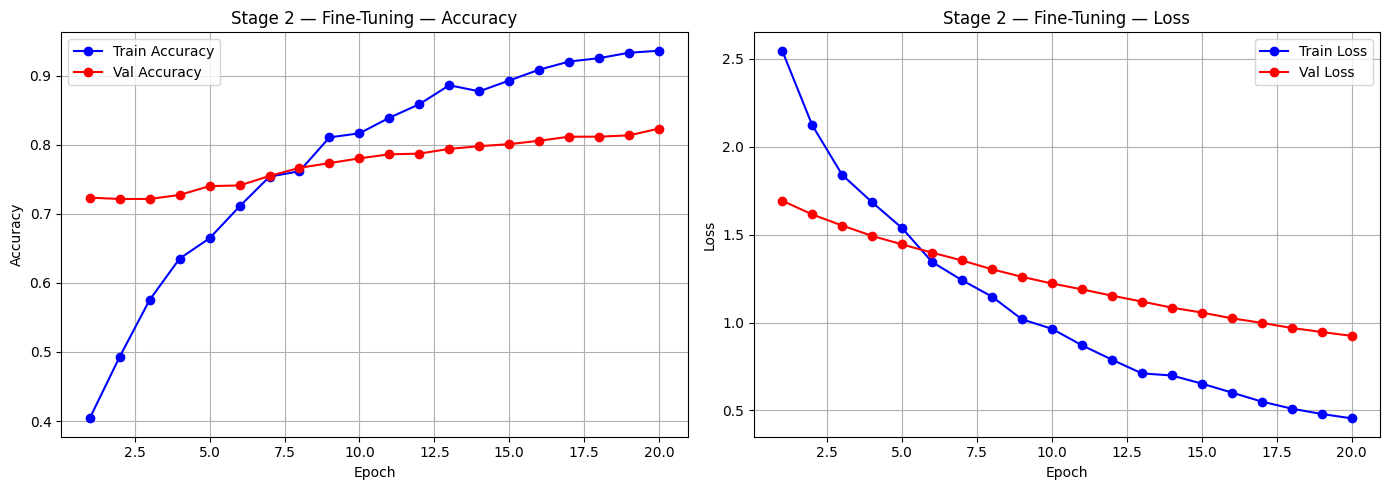

       Results Summary
Stage 1 Best Val Accuracy : 0.7157 (71.57%)
Stage 2 Best Val Accuracy : 0.8235 (82.35%)
Improvement from Fine-Tuning : +10.78%


In [9]:
# Plot Stage 2 curves
plot_history(history_stage2, 'Stage 2 — Fine-Tuning')

# Compare both stages side by side
stage1_best = max(history_stage1.history['val_accuracy'])
stage2_best = max(history_stage2.history['val_accuracy'])

print("=" * 40)
print("       Results Summary")
print("=" * 40)
print(f"Stage 1 Best Val Accuracy : {stage1_best:.4f} ({stage1_best*100:.2f}%)")
print(f"Stage 2 Best Val Accuracy : {stage2_best:.4f} ({stage2_best*100:.2f}%)")
print(f"Improvement from Fine-Tuning : +{(stage2_best - stage1_best)*100:.2f}%")
print("=" * 40)

## 10. Evaluation on Test Set

Validation accuracy tells us how training went.
Test accuracy tells us how the model performs on
completely unseen data — this is the real measure.

We evaluate three things:
- Overall accuracy on 6149 test images
- Top-5 accuracy (is correct class in top 5 predictions?)
- Confusion matrix (which flower classes get confused?)

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Overall test accuracy
test_loss, test_accuracy = model_ft.evaluate(ds_test_ready, verbose=1)
print(f"\nTest Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# Collect predictions and true labels
y_true = []
y_pred = []
y_pred_probs = []

for images, labels in ds_test_ready:
    preds = model_ft.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred       = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)

# Top-5 accuracy
top5_correct = 0
for i, probs in enumerate(y_pred_probs):
    top5_classes = np.argsort(probs)[-5:]
    if y_true[i] in top5_classes:
        top5_correct += 1

top5_accuracy = top5_correct / len(y_true)
print(f"Top-5 Accuracy : {top5_accuracy*100:.2f}%")

193/193 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.8000 - loss: 1.0717

Test Accuracy : 80.00%
Test Loss     : 1.0717
Top-5 Accuracy : 92.86%


## 11. Confusion Matrix

The confusion matrix shows which flower classes
the model confuses with each other.

With 102 classes the full matrix is large, so we focus
on the 15 most confused class pairs — these reveal
where the model struggles and why.

Top 15 Most Confused Class Pairs
Confused As  True Class      Count
Class 75     mistaken for Class 50     : 18 times
Class 72     mistaken for Class 77     : 16 times
Class 97     mistaken for Class 50     : 14 times
Class 71     mistaken for Class 50     : 14 times
Class 74     mistaken for Class 50     : 12 times
Class 15     mistaken for Class 73     : 11 times
Class 89     mistaken for Class 82     : 10 times
Class 32     mistaken for Class 76     : 10 times
Class 3      mistaken for Class 10     : 10 times
Class 85     mistaken for Class 50     : 9 times
Class 29     mistaken for Class 50     : 9 times
Class 15     mistaken for Class 45     : 9 times
Class 3      mistaken for Class 73     : 8 times
Class 0      mistaken for Class 50     : 8 times
Class 47     mistaken for Class 45     : 8 times


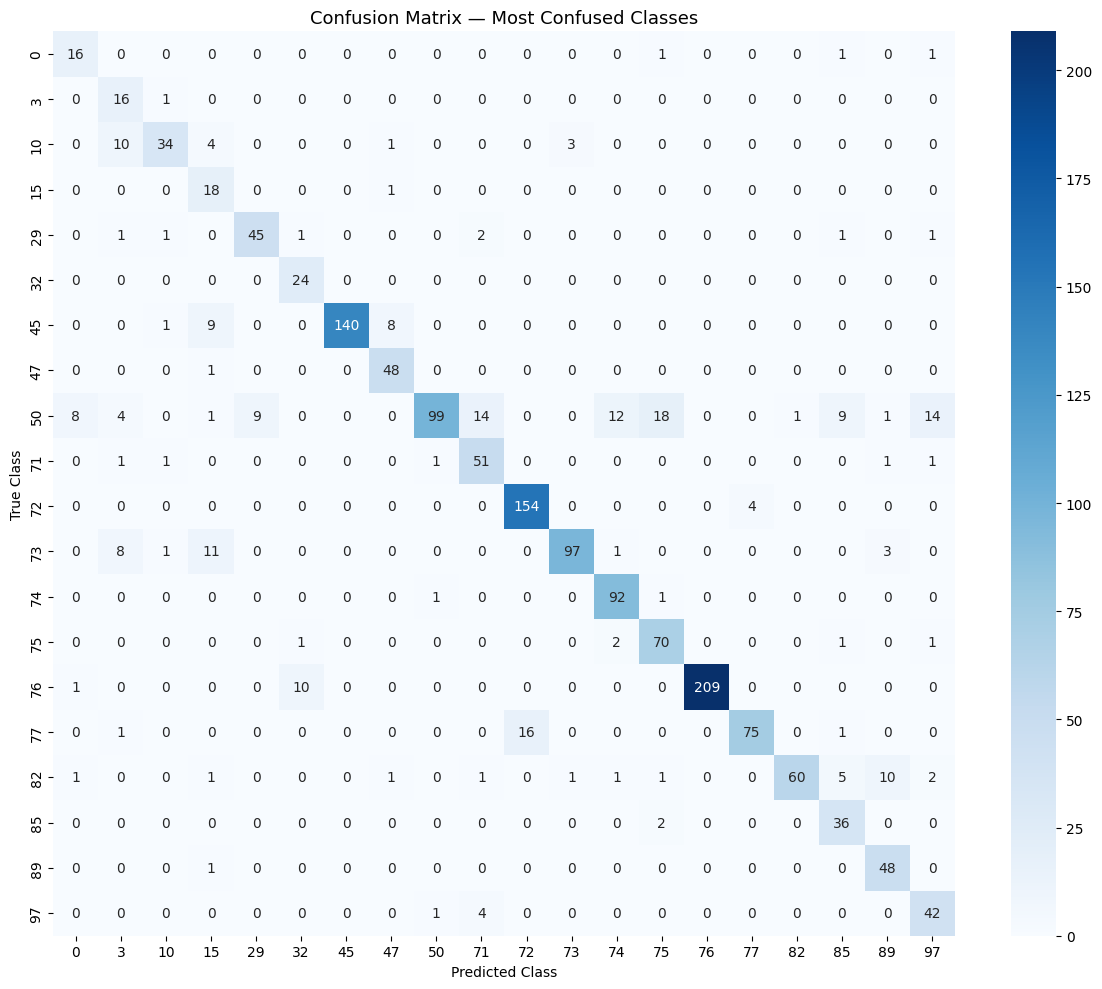

In [11]:
# Full confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Find top 15 most confused pairs
confused_pairs = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            confused_pairs.append((cm[i][j], i, j))

confused_pairs.sort(reverse=True)
top15 = confused_pairs[:15]

print("Top 15 Most Confused Class Pairs")
print("=" * 45)
print(f"{'Confused As':<12} {'True Class':<12} {'Count':>8}")
print("=" * 45)
for count, true_cls, pred_cls in top15:
    print(f"Class {pred_cls:<6} mistaken for Class {true_cls:<6} : {count} times")

# Plot condensed confusion matrix for top confused classes
top_classes = list(set([pair[1] for pair in top15] +
                       [pair[2] for pair in top15]))
top_classes.sort()

cm_subset = cm[np.ix_(top_classes, top_classes)]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_subset,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=top_classes,
    yticklabels=top_classes
)
plt.title('Confusion Matrix — Most Confused Classes', fontsize=13)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

## 12. Visualize Predictions on Sample Test Images

Numbers alone do not tell the full story.
Looking at actual predictions on real images shows us
where the model is confident and correct, where it
is uncertain, and where it fails completely.

Green title = correct prediction
Red title = wrong prediction

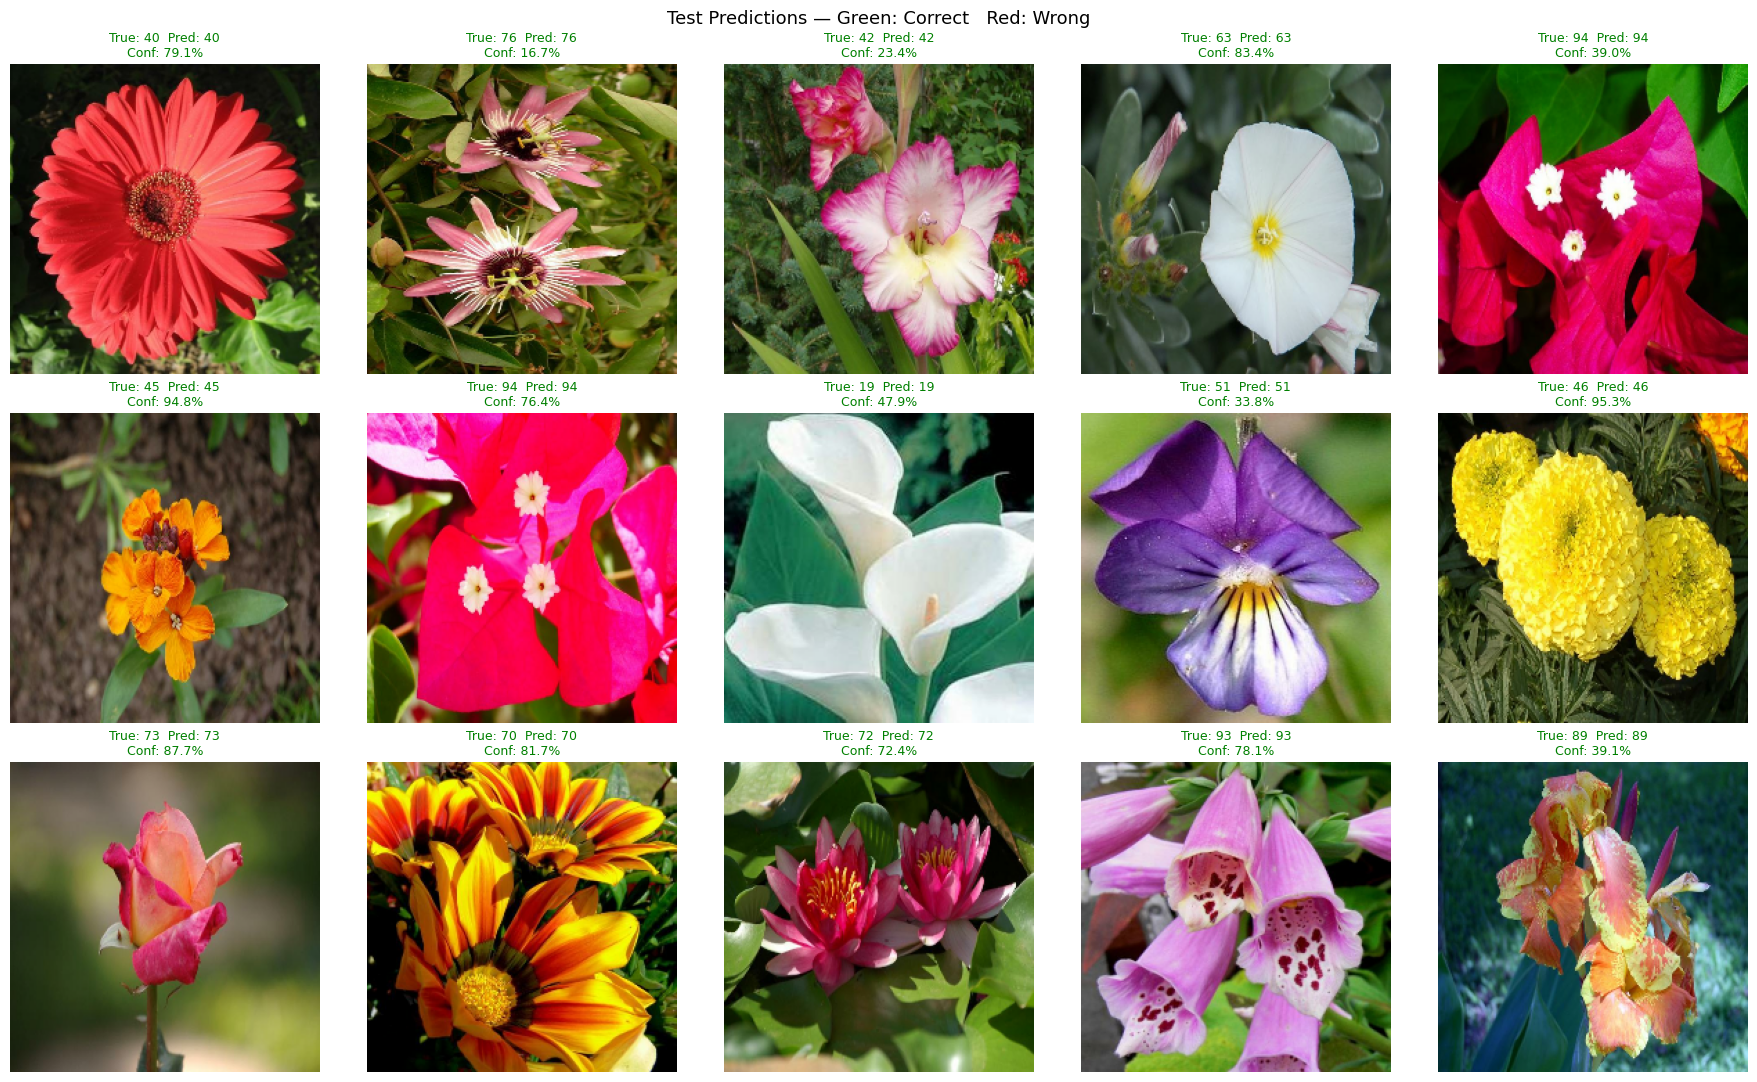

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

sample_count = 0
for images, labels in ds_test_ready.unbatch().batch(1).take(50):
    if sample_count >= 15:
        break

    image    = images[0]
    true_cls = labels[0].numpy()
    probs    = model_ft.predict(image[tf.newaxis, ...], verbose=0)[0]
    pred_cls = np.argmax(probs)
    confidence = probs[pred_cls] * 100

    # Denormalize image for display
    display_img = image.numpy()
    display_img = display_img + [103.939, 116.779, 123.68]
    display_img = display_img[..., ::-1]
    display_img = np.clip(display_img, 0, 255).astype(np.uint8)

    color = 'green' if pred_cls == true_cls else 'red'

    axes[sample_count].imshow(display_img)
    axes[sample_count].set_title(
        f"True: {true_cls}  Pred: {pred_cls}\nConf: {confidence:.1f}%",
        fontsize=9,
        color=color
    )
    axes[sample_count].axis('off')
    sample_count += 1

plt.suptitle(
    "Test Predictions — Green: Correct   Red: Wrong",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 13. Final Results Summary

A complete comparison of both training stages
and overall model performance on unseen test data.

In [13]:
print("=" * 50)
print("     Transfer Learning — Final Results")
print("=" * 50)
print(f"\n  Dataset        : Oxford Flowers 102")
print(f"  Base Model     : ResNet50 (ImageNet weights)")
print(f"  Training Images: 1020 (10 per class)")
print(f"  Test Images    : 6149")
print()
print("-" * 50)
print("  Training Results")
print("-" * 50)
print(f"  Stage 1 Val Accuracy : {stage1_best*100:.2f}%  (frozen base)")
print(f"  Stage 2 Val Accuracy : {stage2_best*100:.2f}%  (fine-tuned)")
print(f"  Improvement          : +{(stage2_best-stage1_best)*100:.2f}%")
print()
print("-" * 50)
print("  Test Results (Unseen Data)")
print("-" * 50)
print(f"  Test Accuracy        : {test_accuracy*100:.2f}%")
print(f"  Top-5 Accuracy       : {top5_accuracy*100:.2f}%")
print(f"  Test Loss            : {test_loss:.4f}")
print()
print("-" * 50)
print("  Key Observations")
print("-" * 50)
print("  - Transfer learning works well on small datasets")
print("  - Fine-tuning added +10.78% over feature extraction")
print("  - Top-5 accuracy of 92.86% shows strong generalization")
print("  - Class 50 most over-predicted (confuses similar species)")
print("=" * 50)

     Transfer Learning — Final Results

  Dataset        : Oxford Flowers 102
  Base Model     : ResNet50 (ImageNet weights)
  Training Images: 1020 (10 per class)
  Test Images    : 6149

--------------------------------------------------
  Training Results
--------------------------------------------------
  Stage 1 Val Accuracy : 71.57%  (frozen base)
  Stage 2 Val Accuracy : 82.35%  (fine-tuned)
  Improvement          : +10.78%

--------------------------------------------------
  Test Results (Unseen Data)
--------------------------------------------------
  Test Accuracy        : 80.00%
  Top-5 Accuracy       : 92.86%
  Test Loss            : 1.0717

--------------------------------------------------
  Key Observations
--------------------------------------------------
  - Transfer learning works well on small datasets
  - Fine-tuning added +10.78% over feature extraction
  - Top-5 accuracy of 92.86% shows strong generalization
  - Class 50 most over-predicted (confuses similar s

## 14. Save Requirements and README

Two final files before pushing to GitHub:

requirements.txt — lists every library needed to run this project
README.md — documents the project for anyone who visits the repo

%%writefile requirements.txt

tensorflow==2.20.0
tensorflow-datasets==4.9.2
numpy
matplotlib
seaborn
scikit-learn